## Лаб3. Вариант 4.2 
### Мяков Измаилов

In [ ]:
import copy
import time

from typing import Callable, Tuple, Callable
from numpy.typing import NDArray

import numpy as np
import cvxpy as cp

from tqdm import tqdm

import matplotlib.pyplot as plt

TOL=0.01

In [3]:
def generate_report(a, b, x_opt, nu_opt, n_iters, timer):
    print(f"\nОптимальное решение: x = {x_opt.round(4)}, ν = {nu_opt:.4f}")
    print(f"Проверка ограничения: {np.dot(a, x_opt).round(4)} (b = {b:.4f})")
    if n_iters and timer:
        print(f"Кол-во иттерация для нахождения оптимальных значений: {n_iters}, время работы метода {timer:.8f}")

**Исследование задачи на выпуклость:**

### 1. **Выпуклость задачи**
- **Целевая функция**: $ f_0(x) = \sum_{i=1}^n x_i^4 $ выпукла, так как:
  - Вторая производная каждой компоненты: $ f_i''(x_i) = 12x_i^2 \geq 0 $.
  - Сумма выпуклых функций выпукла.
  
- **Ограничение**: $ a^T x = b $ — аффинное, а значит, выпуклое множество.

**Вывод**: Задача выпуклая.

---

### 2. **Необходимые условия минимума (KKT)**
Для выпуклых задач условия Караша-Куна-Таккера (KKT) являются необходимыми и достаточными:
1. **Стационарность**:
   $
   \nabla_x L(x, \nu) = 0 \quad \Rightarrow \quad 4x_i^3 + \nu a_i = 0 \quad \forall i.
   $
   Отсюда:
   $
   x_i^* = \left( -\frac{\nu^* a_i}{4} \right)^{1/3}.
   $

2. **Допустимость**:
   $
   a^T x^* = b.
   $

3. **Двойственная допустимость**: Не требуется, так как нет неравенств.

---

### 3. **Двойственная задача**
Лагранжиан:
$
L(x, \nu) = \sum_{i=1}^n x_i^4 + \nu(a^T x - b).
$

Двойственная функция:
$
g(\nu) = \inf_x L(x, \nu) = -b\nu - \sum_{i=1}^n f_i^*(-\nu a_i),
$

где $ f_i^*(y) = \sup_{x_i} (y x_i - x_i^4) = \frac{3}{4^{4/3}} |y|^{4/3} $.

**Двойственная задача**:
$
\text{maximize} \quad -b\nu - \frac{3}{4^{4/3}} \sum_{i=1}^n |\nu a_i|^{4/3}.
$

### Шаги решения задачи оптимизации методом Ньютона

#### 1. **Формулировка условий оптимальности (KKT)**  
Для задачи: <br>

$
\begin{array}{ll}
\text{minimize} & \sum_{i=1}^n f_i(x_i) \\
\text{subject to} & a^T x = b,
\end{array}
$ 

Условия Каруша-Куна-Таккера (KKT) включают:  
1. **Стационарность**:  
   $
   \nabla f_0(x) + \nu \cdot a = 0 \quad \Rightarrow \quad f_i'(x_i) + \nu a_i = 0 \quad \forall i,
   $  
   где $ \nu $ — множитель Лагранжа.  
2. **Допустимость**:  
   $
   a^T x = b.
   $

---

#### 2. **Построение системы уравнений**  
Из условий KKT формируется система: 

$
\begin{cases}
f_1'(x_1) + \nu a_1 = 0, \\
f_2'(x_2) + \nu a_2 = 0, \\
\vdots \\
f_n'(x_n) + \nu a_n = 0, \\
a_1 x_1 + a_2 x_2 + \dots + a_n x_n = b.
\end{cases}
$  

Обозначим вектор переменных как $ \mathbf{z} = [x_1, x_2, \dots, x_n, \nu]^T $.  
Система нелинейных уравнений: $ F(\mathbf{z}) = 0 $.

---

#### 3. **Метод Ньютона для решения системы**  
На каждой итерации:  

1. **Вычисление якобиана** $ J $:  

   $
   J = \begin{bmatrix}
   \frac{\partial F_1}{\partial x_1} & \cdots & \frac{\partial F_1}{\partial x_n} & \frac{\partial F_1}{\partial \nu} \\
   \vdots & \ddots & \vdots & \vdots \\
   \frac{\partial F_n}{\partial x_1} & \cdots & \frac{\partial F_n}{\partial x_n} & \frac{\partial F_n}{\partial \nu} \\
   \frac{\partial F_{n+1}}{\partial x_1} & \cdots & \frac{\partial F_{n+1}}{\partial x_n} & \frac{\partial F_{n+1}}{\partial \nu} \\
   \end{bmatrix},
   $  
   где:  
   - Для $ i = 1, \dots, n $:  
     $
     \frac{\partial F_i}{\partial x_j} = 
     \begin{cases}
     f_i''(x_i), & j = i, \\
     0, & j \neq i,
     \end{cases}, \quad \frac{\partial F_i}{\partial \nu} = a_i.
     $  
   - Для $ F_{n+1} $:  
     $
     \frac{\partial F_{n+1}}{\partial x_j} = a_j, \quad \frac{\partial F_{n+1}}{\partial \nu} = 0.
     $  

2. **Нахождение $ \Delta $ z**: 

   $
   \Delta \mathbf{z} = J^{-1} \cdot -F(\mathbf{z}),
   $  
   где $ \Delta \mathbf{z} = [\Delta x_1, \dots, \Delta x_n, \Delta \nu]^T $.

3. **Обновление переменных**:  
   
   $
   \mathbf{z}^{(k+1)} = \mathbf{z}^{(k)} + \Delta \mathbf{z}.
   $


#### 4. **Алгоритм**  
1. **Инициализация**:  

   - Выбрать начальное приближение $ x^{(0)} $, удовлетворяющее $ a^T x^{(0)} = b $, и $ \nu^{(0)} $.  
2. **Итерации**:  

   - Пока норма $ F(\mathbf{z}) $ не станет меньше заданного допуска $ \epsilon $:  
     - Вычислить $ F(\mathbf{z}) $ и $ J $.  
     - Находим $ \Delta \mathbf{z} $.  
     - Обновить $ \mathbf{z} $.  


In [4]:
class NewtonMethod:
    def __init__(
        self, 
        func: Callable, 
        f_prime: Callable, 
        f_double_prime: Callable
    ):
        self.func = func
        self.f_prime = f_prime
        self.f_double_prime = f_double_prime
        
    def optimize(
        self,
        a: NDArray, 
        b: float, 
        x0: NDArray, 
        nu0: float, 
        tol: float=0.01, 
        max_iter: int=100
    ) -> Tuple[NDArray, float, int, float]:
        
        n = len(x0)
        x = x0.copy()
        nu = nu0
        self.x_values = [x0]
        
        s_time = time.time()
        
        for iter_idx in range(max_iter):

            F = np.zeros(n + 1)
            F[:n] = self.f_prime(x) + nu * a
            F[-1] = np.dot(a, x) - b

            J = np.zeros((n + 1, n + 1))
            J[:n, :n] = np.diag(self.f_double_prime(x))
            J[:n, -1] = a
            J[-1, :n] = a
            J[-1, -1] = 0

            delta_z = np.linalg.inv(J) @ -F
            
            if np.linalg.norm(F) < tol:
                break
            
            x += delta_z[:n]
            nu += delta_z[-1]
            
            self.x_values.append(copy.deepcopy(x))
            
            if np.linalg.norm(F) < tol:
                break
    
        return (
            x, 
            nu, 
            iter_idx + 1, 
            time.time() - s_time
        )

In [5]:
def func(x_i: NDArray):
    return sum(x_i ** 4)

def f_prime(x_i: NDArray):
    return 4 * x_i**3

def f_double_prime(x_i: NDArray):
    return 12 * x_i**2

In [6]:
newton_solver = NewtonMethod(func=func, f_prime=f_prime, f_double_prime=f_double_prime)

a = np.array([1, 1])
b = 2
nu0 = 0
x0 = np.array([4.0, 1.0])

x_opt, nu_opt, n_iters, timer = newton_solver.optimize(a, b, x0, nu0=nu0, tol=0.01)
generate_report(a, b, x_opt, nu_opt, n_iters, timer)


Оптимальное решение: x = [1. 1.], ν = -3.9998
Проверка ограничения: 2.0 (b = 2.0000)
Кол-во иттерация для нахождения оптимальных значений: 6, время работы метода 0.00087690


In [7]:
n = 10

a = np.random.randn(n)
x0 = np.random.randn(n)
x_true = np.random.randn(n)
b = a @ x_true

x = cp.Variable(n)
objective = cp.Minimize(cp.sum(cp.power(x, 4)))
constraint = [a @ x == b]

problem = cp.Problem(objective, constraint)
problem.solve()

if problem.status != cp.OPTIMAL:
    print(f"Пример не удалось решить.")

x_opt, nu_opt, n_iters, timer = newton_solver.optimize(a, b, x0, nu0=nu0, max_iter=100, tol=TOL)

### Шаги решения двойственной задачи методом Ньютона

#### 1. **Двойственная задача**  
Максимизировать функцию:  

$
g(\nu) = -b\nu - \sum_{i=1}^n f_i^*(-\nu a_i),
$  

где $ f_i^*(-\nu a_i) = \frac{3}{4^{4/3}} |\nu a_i|^{4/3} $.

---

#### 2. **Первая и вторая производные $ g(\nu) $**  
1. **Первая производная**:  

   $
   g'(\nu) = -b - \frac{3}{4^{4/3}} \cdot \frac{4}{3} \sum_{i=1}^n \text{sign}(\nu) \cdot |\nu a_i|^{1/3} \cdot a_i.
   $  

   Упрощение: 

   $
   g'(\nu) = -b - \frac{4}{4^{4/3}} \sum_{i=1}^n |\nu|^{1/3} \cdot |a_i|^{4/3}.
   $


2. **Вторая производная**:  

   $
   g''(\nu) = -\frac{4}{4^{4/3}} \cdot \frac{1}{3} \sum_{i=1}^n |\nu|^{-2/3} \cdot |a_i|^{4/3}.
   $  

   Упрощение:  

   $
   g''(\nu) = -\frac{4}{3 \cdot 4^{4/3}} \sum_{i=1}^n \frac{|a_i|^{4/3}}{|\nu|^{2/3}}.
   $

---

#### 3. **Итерации метода Ньютона**  
Обновление множителя $ \nu $:  

$
\nu^{(k+1)} = \nu^{(k)} - \frac{g'(\nu^{(k)})}{g''(\nu^{(k)})}.
$

In [8]:
class DualNewtonMethod:    
    def __init__(
        self,  
        f_prime: Callable, 
        f_double_prime: Callable,
        f_x: Callable
    ):
        self.f_prime = f_prime
        self.f_double_prime = f_double_prime
        self.f_x = f_x

    def optimize(
        self,
        a: NDArray, 
        b: float, 
        nu0: float, 
        tol: float=1e-6, 
        max_iter: int=100
    ) -> Tuple[NDArray, float]:
        
        nu = nu0
        self.nu_values = [nu]
        
        s_time = time.time()
        
        for iter_idx in range(max_iter):

            gv_prime = self.f_prime(nu, a, b)
            gv_double_prime = self.f_double_prime(nu, a)

            nu -= (gv_prime / gv_double_prime)
            
            while True:
                if a @ self.f_x(nu, a) - b < 1e-6:
                    break
                nu *= 0.5
            
            self.nu_values.append(copy.deepcopy(nu))
            
            if np.abs(gv_prime) < tol:
                break
        
        method_time = time.time() - s_time
        
        self.x_values = [self.f_x(nu, a) for nu in self.nu_values]
        
        return (
            self.f_x(nu, a), 
            nu, 
            iter_idx + 1, 
            method_time
        )

In [9]:
def gv_prime(nu, a, b):
    return -b - (4 ** (-1/3)) * np.sum(a * np.cbrt(nu * a))
    
def gv_double_prime(nu, a):
    return - ((4 ** (-1/3)) / 3) * np.sum(a ** 2 / ((np.abs(nu * a) + 1e-7) ** (2/3)))

def f_x(nu, a):
    return - np.cbrt((nu * a) / 4)

dual_newton_solver = DualNewtonMethod(f_prime=gv_prime, f_double_prime=gv_double_prime, f_x=f_x)

In [25]:
n = 10

a = np.random.random(n)
x0 = np.random.random(n)
x_true = np.random.random(n)
b = a @ x_true

x = cp.Variable(n)
objective = cp.Minimize(cp.sum(cp.power(x, 4)))
constraint = [a @ x == b]

problem = cp.Problem(objective, constraint)
problem.solve()

if problem.status != cp.OPTIMAL:
    print(f"Пример не удалось решить.")
    
x.value

array([0.29901387, 0.21868058, 0.1680214 , 0.18352595, 0.30982942,
       0.31093274, 0.28585872, 0.14946101, 0.22970302, 0.28489573])

#### Эксперименты

In [28]:
print(f"Реальный x_opt = {x.value.round(4)}")
print(f"Проверка ограничения: aᵀx = {np.dot(a, x.value):.4f} (b = {b:.4f})")

print('\n\nPrimal problem')
x_opt, nu_opt, n_iters, timer = newton_solver.optimize(a, b, x0, nu0=1, tol=TOL)
generate_report(a, b, x_opt, nu_opt, n_iters, timer)

print('\n\nDual problem')
x_opt, nu_opt, n_iters, timer = dual_newton_solver.optimize(a, b, nu0=-1, tol=TOL)
generate_report(a, b, x_opt, nu_opt, n_iters, timer)

Реальный x_opt = [0.299  0.2187 0.168  0.1835 0.3098 0.3109 0.2859 0.1495 0.2297 0.2849]
Проверка ограничения: aᵀx = 1.5726 (b = 1.5726)


Primal problem

Оптимальное решение: x = [0.2988 0.2185 0.1738 0.1834 0.3096 0.3107 0.2857 0.1494 0.2296 0.2847], ν = -0.1202
Проверка ограничения: 1.5726 (b = 1.5726)
Кол-во иттерация для нахождения оптимальных значений: 12, время работы метода 0.00136089


Dual problem

Оптимальное решение: x = [0.299  0.2187 0.168  0.1835 0.3098 0.3109 0.2859 0.1495 0.2297 0.2849], ν = -0.1204
Проверка ограничения: 1.5726 (b = 1.5726)
Кол-во иттерация для нахождения оптимальных значений: 5, время работы метода 0.00036001


#### Генерация тестовых примеров

In [14]:
dimensions = range(10, 101, 10)  
N = 100 
test_cases = {
    n: [] for n in dimensions
}


for n in dimensions:
    for example in range(N):
        a = np.random.random(n)
        x_true = np.random.random(n)
        b = a @ x_true
        
        x = cp.Variable(n)
        objective = cp.Minimize(cp.sum(cp.power(x, 4)))
        
        constraint = [a @ x == b]
        
        problem = cp.Problem(objective, constraint)
        problem.solve()
        
        if problem.status != cp.OPTIMAL:
            print(f"Пример {example + 1} для n={n} не удалось решить.")

        test_case = {
            'a': a,
            'b': b,
            'x_opt': x.value if problem.status == cp.OPTIMAL else None,
        }
            
        test_cases[n].append(test_case)
        
print("Все тест-кейсы сгенерированы.")

Все тест-кейсы сгенерированы.


#### Эксперименты (прямой метод)

In [15]:
results = {
    n: [] for n in dimensions
}
errors = 0

dual_results = {
    n: [] for n in dimensions 
}
dual_errors = 0

for dim in tqdm(dimensions):
    for case in test_cases[dim]:

        a = case['a']
        b = case['b']
        x_opt = case['x_opt']

        for _ in range(10):
            x0 = np.random.randn(dim)
            nu0 = np.random.randn()
            
            x_opt, nu_opt, iters, timer = newton_solver.optimize(a, b, x0, nu0=nu0, tol=TOL)

            if abs(a @ x_opt - b) < 1e-6:
                results[dim].append({
                    'x0': x0,
                    'x': x_opt,
                    'nu': nu_opt,
                    'iters': iters,
                    'time': timer,
                })
            else:
                print(f"\n\nПроверка ограничения в прямом методе не пройдена\n")
                errors += 1
                
            x_opt, nu_opt, iters, timer = dual_newton_solver.optimize(a, b, nu0=nu0, tol=TOL)

            if abs(a @ x_opt - b) - b < 1e-6:
                dual_results[dim].append({
                    'x': x_opt,
                    'nu': nu_opt,
                    'iters': iters,
                    'time': timer,
                })
            else:
                print(f"\n\nПроверка ограничения в двойственном методе не пройдена\n")
                dual_errors += 1
            

100%|██████████| 10/10 [00:14<00:00,  1.49s/it]


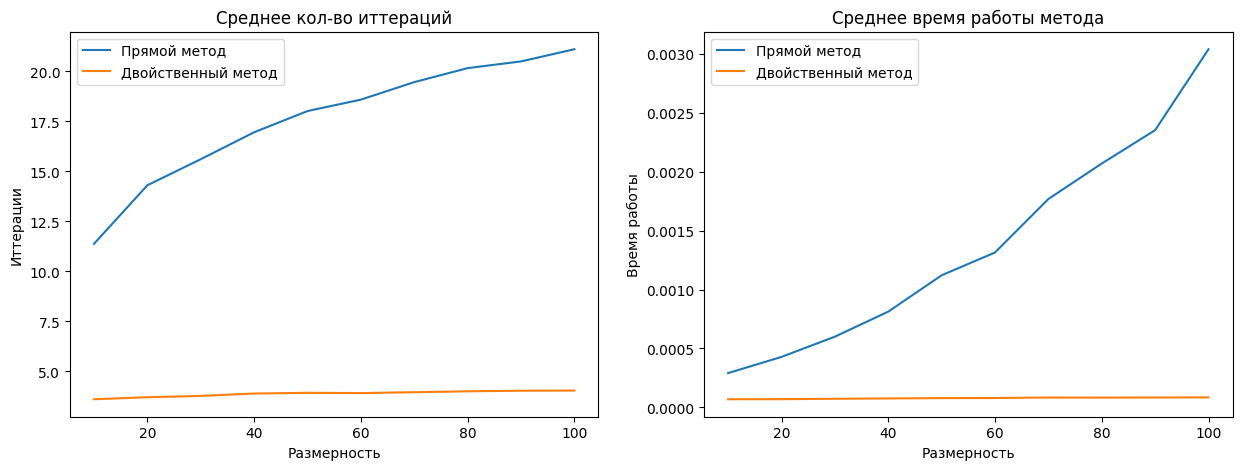

In [16]:
avg_iters = [(np.mean([test['iters'] for test in results[n_dim]])) for n_dim in results]
avg_time = [(np.mean([test['time'] for test in results[n_dim]])) for n_dim in results]

dual_avg_iters = [(np.mean([test['iters'] for test in dual_results[n_dim]])) for n_dim in dual_results]
dual_avg_time = [(np.mean([test['time'] for test in dual_results[n_dim]])) for n_dim in dual_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(dimensions, avg_iters, label='Прямой метод')
ax1.plot(dimensions, dual_avg_iters, label='Двойственный метод')
ax1.set_title('Среднее кол-во иттераций')
ax1.set_ylabel('Иттерации')
ax1.set_xlabel('Размерность')
ax1.legend()

ax2.plot(dimensions, avg_time, label='Прямой метод')
ax2.plot(dimensions, dual_avg_time, label='Двойственный метод')
ax2.set_title('Среднее время работы метода')
ax2.set_ylabel('Время работы')
ax2.set_xlabel('Размерность')
ax2.legend();

### Подсчет арифметических операций

#### **1. Прямой метод Ньютона**
**Шаги и сложность:**
1. **Вычисление Лагранжиана** - $ O(n) $ операций;
2. **Вычисление Гессиана** - $ O(n) $ операций;
3. **Обратная матрица** - $ O(n^3) $ операций;
5. **Обновление значений** - $ O(1) $ операций

**Итоговая сложность одной итерации**:  
$
O(n^3)
$

---

#### **2. Двойственный метод Ньютона**
**Шаги и сложность:**
1. **Вычисление первой производной** - $ O(n) $ операций;
2. **Вычисление второй производной** - $ O(n) $ операций;
3. **Обновление значений** - $ O(1) $ операций

**Итоговая сложность одной итерации**:  
$
O(n)
$


#### Зависимость точности по значению функции от числа итераций

In [17]:
newton_solver = NewtonMethod(func=func, f_prime=f_prime, f_double_prime=f_double_prime)
dual_newton_solver = DualNewtonMethod(f_prime=gv_prime, f_double_prime=gv_double_prime, f_x=f_x)

dim = 10

a = np.random.randn(dim)
x_true = np.random.randn(dim)
b = a @ x_true

optimal_x = cp.Variable(dim)
objective = cp.Minimize(cp.sum(cp.power(optimal_x, 4)))
constraint = [a @ optimal_x == b]

problem = cp.Problem(objective, constraint)
problem.solve()

if problem.status != cp.OPTIMAL:
    print(f"Пример не удалось решить.")
    
true_y = func(optimal_x.value)

In [22]:
accuracy = []
dual_accuracy = []

for _ in tqdm(range(10)):
    x0 = np.random.randn(dim)
    nu0 = np.random.randn()
    
    _ = newton_solver.optimize(a, b, x0, nu0=nu0, tol=TOL)
    accuracy.append([np.abs(true_y - func(x_opt)) for x_opt in newton_solver.x_values])
    
    _ = dual_newton_solver.optimize(a, b, nu0=nu0, tol=TOL)
    dual_accuracy.append([np.abs(true_y - func(x_opt)) for x_opt in dual_newton_solver.x_values])

100%|██████████| 10/10 [00:00<00:00, 1217.75it/s]


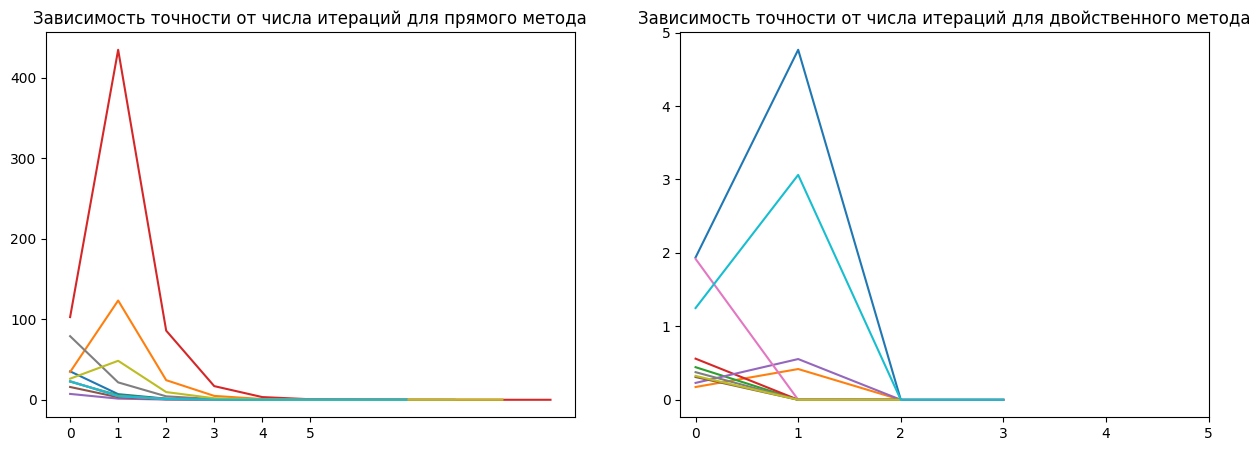

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.set_title('Зависимость точности от числа итераций для прямого метода')
for acc in accuracy:
    ax1.plot(range(len(acc)), acc)
ax1.set_xticks([0, 1, 2, 3, 4, 5])
    
    
ax2.set_title('Зависимость точности от числа итераций для двойственного метода')
for acc in dual_accuracy:
    ax2.plot(range(len(acc)), acc)
ax2.set_xticks([0, 1, 2, 3, 4, 5])

plt.show();